## CountVectorizer

在使用 CountVectorizer 時，
指定 stop_words='english' 會自動移除英文中的常見停用詞（stop words），
例如 "this" 和 "is"。停用詞是一些在文本分析中不具有區分度的常見單詞，例如冠詞、連詞和一些代詞。這些單詞通常對文本的主題或意圖沒有太大的貢獻，所以在計算特徵時會被移除。

In [1]:
text = ['This is a line',

           "This is another line",
           
       "Completely different line"]

In [3]:
from sklearn.feature_extraction.text import TfidfTransformer,TfidfVectorizer,CountVectorizer
cv = CountVectorizer(stop_words='english')
counts =  cv.fit_transform(text)
counts.todense()

matrix([[0, 0, 1],
        [0, 0, 1],
        [1, 1, 1]], dtype=int64)

In [ ]:
cv.vocabulary_
# 'line': 2, 'completely': 0, 'different': 1 數字表示欄位

{'line': 2, 'completely': 0, 'different': 1}


簡單來說，`TfidfTransformer` 就是一個「幫字詞打分數」的工具，它會把你原本的詞頻（也就是某個字在文件中出現了多少次）轉換成更有區別度的「TF–IDF 分數」。

1. **TF（Term Frequency，詞頻）**：衡量一個詞在一篇文件裡出現的頻率。出現越多，原始分數越高。
2. **IDF（Inverse Document Frequency，逆文件頻率）**：衡量一個詞在整個語料庫（所有文件）中有多「罕見」。如果一個詞在很多文件裡都出現（像「的」、「是」這種常見字），它的 IDF 會很低；只有少數文件裡才出現的詞（像「電腦視覺」、「隨機森林」）IDF 會比較高。

`TfidfTransformer` 會把這兩者「相乘」：

$$
\text{TF–IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{DF}(t)}
$$

* $t$ 是詞，$d$ 是文件
* $N$ 是文件總數，$\text{DF}(t)$ 是包含詞 $t$ 的文件數

**為什麼要這麼做？**

* 把在特定文件中很重要（頻繁出現），但在整體語料庫中又很少見的詞，打上高分。
* 把那些雖然在文件裡出現很多次，卻在所有文件裡都常見的詞，打上低分。

這樣一來，你在做後續機器學習或相似度比對時，就能更容易「抓到」那些真正能區分文件意義的關鍵字，而不是被高頻的「停用詞」干擾。


**舉例TF-IDF應用**

我會根據用戶問題提供一個實際的例子，用來解釋TF-IDF。這方面，我可以探討像是“蘋果手機”這類專有名詞，出現在某些文檔中頻繁卻重要性較高的詞彙；而“的”這類中文常見停用詞，雖然出現頻繁，但TF-IDF值會較低。為了更清楚，我可以展示一個小範例，通過簡單的數字來說明這些詞彙在TF-IDF計算中的表現。

**說明TF-IDF範例**

我可以舉兩個例子來區分“常出現但不重要”和“常出現但重要”的詞彙。“的”在所有文檔中都會出現，因此IDF很低，TF高，但TF-IDF低；而“蘋果手機”在第一篇文檔中出現兩次，其他文檔比較少，也因此TF和IDF都較高，因此TF-IDF較高。簡單來說，“蘋果手機”在特定文檔中出現頻繁且重要，而“的”雖然常見卻對於區分意圖的文檔來說沒有重要性。

**解釋TF-IDF範例**

“常出現但不重要”如“的”這樣的停用詞，通常在所有文檔中頻繁出現，IDF很低，因此TF-IDF並不高。而如“Quibli”，它在特定領域的文章中頻繁出現但在其他地方很少見，IDF則高，TF-IDF就會很高，顯示它對該文章很重要。另外，如果在不同運動領域的文章中，像“湖人”這樣的詞彙可能顯得很重要，若只在拳擊文章中出現，每篇都帶來高TF-IDF。


已思考 29 秒鐘


以下用一個簡單的「籃球賽報導」小語料庫舉例，說明兩類「常出現」的詞：

1. **常出現但不重要**（停用詞／泛用詞）
2. **常出現且重要**（能區分本文主題的關鍵詞）

---

## 語料庫（共 3 篇短文）

* **Doc1（湖人隊比賽）**

  > 「湖人 在 今晚 的比賽 中 以 102：98 戰勝 勇士，球員的表現 出色。」

* **Doc2（勇士隊新聞）**

  > 「勇士 球隊球員今季新秀的表現 穩定，但 在 防守 端 仍 有 改善 空間。」

* **Doc3（一般體育新聞）**

  > 「今年的體育 賽事 因 為 天候 的影響 而 延期，眾多 球迷 只能 在 電視 前 觀賽。」

設 $N=3$。計算幾個詞在 **Doc1** 中的 TF–IDF：

|  詞彙 | Doc1 中 TF | DF（出現過的文件數） | IDF = $\log\frac{N}{\text{DF}}$ |  TF–IDF = TF × IDF |         分類        |
| :-: | :-------: | :---------: | :-----------------------------: | :----------------: | :---------------: |
|  的  |     2     |      3      |       $\log\frac{3}{3}=0$       |    $2\times0=0$    |    常見停用詞 → 不重要    |
|  球員 |     1     |      2      |   $\log\frac{3}{2}\approx0.18$  | $1\times0.18=0.18$ | 常見詞，但多篇都有提 → 不太區分 |
|  湖人 |     1     |      1      |   $\log\frac{3}{1}\approx1.10$  | $1\times1.10=1.10$ |     本文主題 → 重要     |
|  戰勝 |     1     |      1      |   $\log\frac{3}{1}\approx1.10$  | $1\times1.10=1.10$ |     本文事件 → 重要     |

* **「的」**：停用詞，雖然在 Doc1 出現 2 次（TF 高），但因為在所有 3 篇都出現（DF=3），IDF=0，最終 TF–IDF=0 → 不重要。
* **「球員」**：在 Doc1 出現 1 次，但同時 Doc2 也提到（DF=2），IDF 約 0.18，所以 TF–IDF 也很低 → 雖「常出現」，卻不具辨別力。
* **「湖人」、「戰勝」**：都只在 Doc1 出現（DF=1），IDF≈1.10，TF–IDF≈1.10 → 不僅常出現，而且是報導的核心詞，分數高 → 重要。

---

### 小結

* **常出現但不重要**：像「的」、「球員」，即使在一篇文中頻繁出現，因為在多篇文都會出現，IDF 低、TF–IDF 低 → 適合視為停用或次要詞。
* **常出現且重要**：像「湖人」、「戰勝」，在目標文件中頻繁出現，但在整體語料庫中少見，IDF 高、TF–IDF 高 → 最能凸顯該文件獨特內容。

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### The Data

Source: https://www.kaggle.com/crowdflower/twitter-airline-sentiment?select=Tweets.csv

This data originally came from Crowdflower's Data for Everyone library.

As the original source says,

A sentiment analysis job about the problems of each major U.S. airline. Twitter data was scraped from February of 2015 and contributors were asked to first classify positive, negative, and neutral tweets, followed by categorizing negative reasons (such as "late flight" or "rude service").

#### The Goal: Create a Machine Learning Algorithm that can predict if a tweet is positive, neutral, or negative. In the future we could use such an algorithm to automatically read and flag tweets for an airline for a customer service agent to reach out to contact.


### 資料來源

來源：https://www.kaggle.com/crowdflower/twitter-airline-sentiment?select=Tweets.csv

這些資料最初來自 Crowdflower 的「Data for Everyone」資料庫。

根據原始來源所述，

這是一個關於美國主要航空公司問題的情感分析工作。Twitter 數據是從 2015 年 2 月收集的，並且請求貢獻者首先將推文分類為正面、負面和中性，然後再分類負面原因（例如「航班延誤」或「服務粗魯」）。

#### 目標：建立一個機器學習算法來預測推文是正面、中性還是負面。在未來，我們可以使用這樣的算法自動閱讀並標記航空公司的推文，讓客服人員聯繫客戶。

In [6]:
df = pd.read_csv("./airline_tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: xlabel='airline', ylabel='count'>

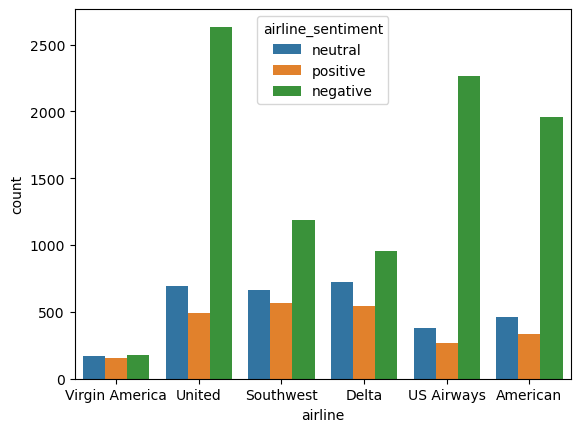

In [7]:
sns.countplot(data=df,x="airline",hue="airline_sentiment")

In [9]:
data = df[["text","airline_sentiment"]]
data.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [10]:
y = df["airline_sentiment"]
X = df["text"]

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [13]:
tfdif = TfidfVectorizer(stop_words="english")
tfdif.fit(X_train)
X_train_tfidf = tfdif.transform(X_train)
X_test_tfidf = tfdif.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()#文字分類、詞頻專用的
#給定特徵 X（例如一段文字），預測它的標籤 y（例如情緒正面或負面）。
#整份文件中，某個詞如果在負面情緒的訓練資料中常出現、重要性高，
#那未來看到這個詞時，模型就會偏向判它為負面。
nb.fit(X_train_tfidf,y_train)

MultinomialNB()

In [15]:
tes = tfdif.transform(["@SouthwestAir thanks! Very "])
pred = nb.predict(tes)
print(pred)

['positive']


# 多數決演算法(VotingClassifier)測試

In [16]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np

In [17]:
## 載入資料集
X, y = datasets.load_breast_cancer(return_X_y=True)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()#連續值連續型數字的
gnb.fit(X_train_std, y_train)
print(f"{gnb.score(X_test_std, y_test):.2f}")

0.93


In [24]:
## 模型訓練
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
estimators = [("svc",SVC()),("rf",RandomForestClassifier()),("nb",GaussianNB())]
clf = VotingClassifier(estimators)
clf.fit(X_train_std,y_train)

VotingClassifier(estimators=[('svc', SVC()), ('rf', RandomForestClassifier()),
                             ('nb', GaussianNB())])

In [25]:
print(f"{clf.score(X_test_std,y_test):.2f}")

0.95


## 強化法(Boosting)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

from sklearn.datasets import load_digits

In [27]:
dataset = load_digits()
X = dataset["data"]
y = dataset["target"]

4


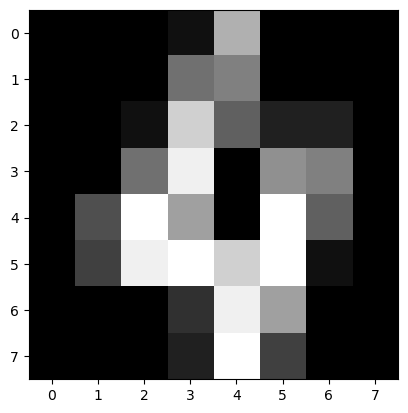

In [31]:
plt.imshow(X[4].reshape(8,8),cmap="gray")
print(y[4])

In [32]:
clf= DecisionTreeClassifier(max_depth=10)
score_dc = cross_val_score(clf,X,y,cv = 6)
score_dc.mean()

0.7958138238573021

## AdaBoost模型評估

SAMME

的基本思想是通過多次迭代訓練分類器，每次迭代中調整樣本權重，使得錯誤分類的樣本在後續迭代中具有更大的權重，從而加強對這些錯誤樣本的學習。

In [33]:
clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=10),algorithm="SAMME")
scores_ada =  cross_val_score(clf,X,y,cv = 6)
print(scores_ada.mean())

0.9521404682274248


# XGBoost測試

In [34]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [37]:
boston = pd.read_csv("./california_housing_dataset.csv")
X = boston.drop(["Target"],axis=1)
y = boston["Target"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Mean squared error: {mean_squared_error(y_test, y_pred)}")

Mean squared error: 0.2225899267544737


In [41]:
## 使用分類模型
from xgboost import XGBClassifier
X,y = datasets.load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
model = XGBClassifier()
model.fit(X_train,y_train)
score = cross_val_score(model,X_test,y_test,cv=10)
print(f"平均分數:{np.mean(score)}")

平均分數:0.9287878787878787


## Kmeans

In [62]:
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=150,
                 n_features=2,
                 centers=3,
                 cluster_std=0.5,
                 shuffle=True,
                 random_state=0)
# 150筆資料 2個特徵 分成3群 標準差0.5 是否重新洗牌shuffle

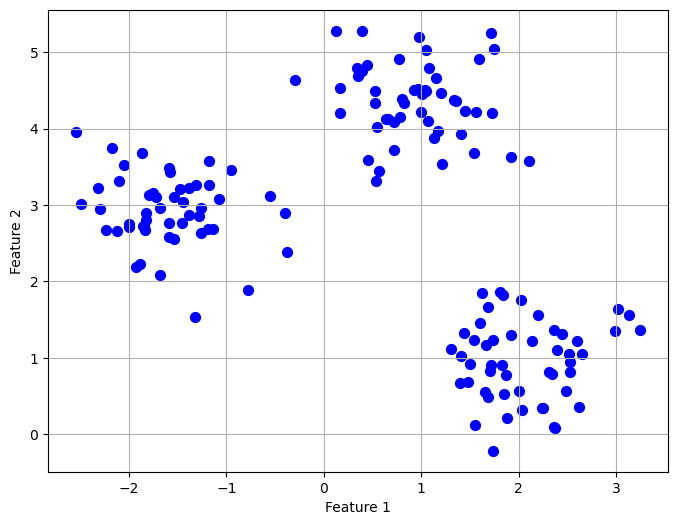

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c="blue",marker="o",s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [56]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2,init="k-means++",max_iter=300,random_state=0)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


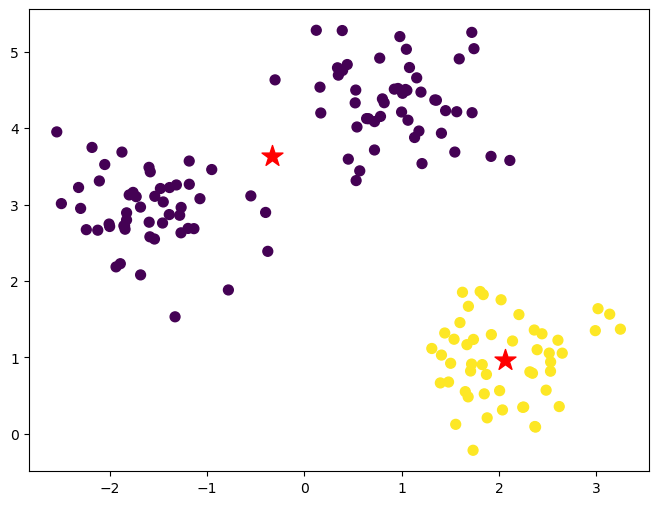

In [57]:
y_km = km.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y_km,marker="o",s=50,cmap="viridis")
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],s=250,marker="*",c="red",label="centers")


In [ ]:
km.inertia_ 
#km.inertia_ 所有點到它們所屬群中心的距離平方總和（Sum of Squared Distances, SSD）
#Inertia 越小越好

283.46101780209307

In [58]:
distortions = []
for i in range(1,11):
    km = KMeans(n_clusters=i,init="k-means++",max_iter=300,random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)

for i in range(0,len(distortions)):
    print(i,distortions[i]) 

0 713.6998289434159
1 283.46101780209307
2 72.47601670996698
3 67.30934494757155
4 58.65546094894906
5 51.37648198195417
6 41.87680035829947
7 35.98988395951002
8 33.514211339645755
9 29.50793550053656


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

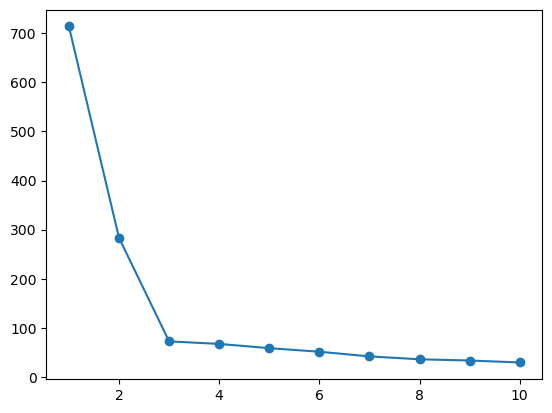

In [59]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),distortions,marker="o")


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


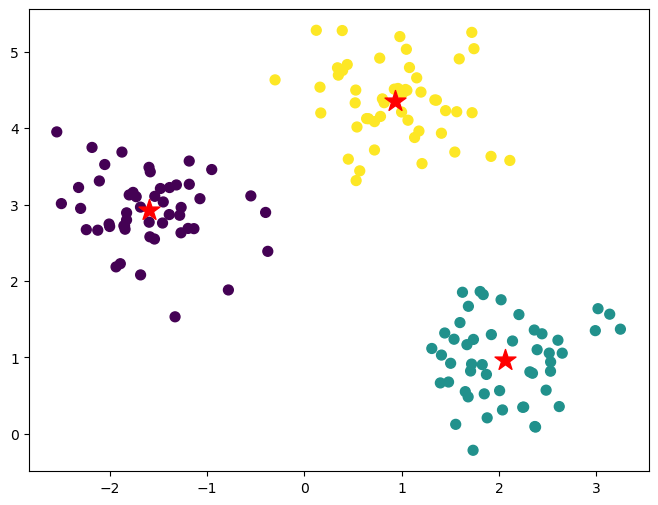

In [61]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3,init="k-means++",max_iter=300,random_state=0)


y_km = km.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y_km,marker="o",s=50,cmap="viridis")
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],s=250,marker="*",c="red",label="centers")


## silhouette_score 輪廓係數
它在看：同一群是不是夠近、不同群是不是夠遠

分數範圍：

-1 ~ 1

越接近 1 → 分群越好

接近 0 → 分群很模糊

負數 → 分得很爛


# 手動計算範例（1D，距離=差的絕對值）

假設我們已經分好兩群：

* **群 A**：1、2、3
* **群 B**：8、9、10

我們要算的點 **i** 選「2」（在群 A 裡）。

距離規則（1D 很簡單）：
$$
d(x,y)=|x-y|
$$

---

## 1) 先算 a(i)：我跟「自己人」有多近（群內平均距離）

點 i = 2，同群 A 其他點是 1 和 3

* 距離(2,1) = |2-1| = 1
* 距離(2,3) = |2-3| = 1

平均：

$$
a(i)=\frac{1+1}{2}=1
$$

**我跟同一群的人平均差 1（很近）**

---

## 2) 再算 b(i)：我跟「最近的別群」有多遠（群外平均距離）

別群只有 B：8、9、10

* 距離(2,8)=|2-8|=6
* 距離(2,9)=|2-9|=7
* 距離(2,10)=|2-10|=8

平均：

$$
b(i)=\frac{6+7+8}{3}=\frac{21}{3}=7
$$

**我跟隔壁那群平均差 7（很遠）**

---

## 3) 套公式算 s(i)

公式：

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

代入 a(i)=1，b(i)=7：

* 分子：b-a = 7-1 = 6
* 分母：max(1,7) = 7

$$
s(i)=\frac{6}{7}\approx 0.857
$$

結果**0.857 很接近 1 → 這個點分得超好**

---

> **a(i)**：我跟自己這群的人平均有多近（越小越好）
> **b(i)**：我跟最近的別群平均有多遠（越大越好）
> **s(i)**：把「外人比自己人遠多少」用比例表示出來（所以一定落在 -1 到 1）
---


In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [64]:
import numpy as np
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)

In [66]:
scores = []
for k in range(2,10):
    km = KMeans(n_clusters=k,init="k-means++",max_iter=300,random_state=0)
    labes = km.fit_predict(X)
    score = silhouette_score(X,labes)
    scores.append((k,score))
#根據scores的分數高到低排序
scores.sort(key=lambda x:x[1],reverse=True)

for k,s in scores:
    print(f"K={k},silhouette_score={s:.3f}")    
    

K=3,silhouette_score=0.714
K=2,silhouette_score=0.585
K=4,silhouette_score=0.564
K=6,silhouette_score=0.458
K=5,silhouette_score=0.437
K=8,silhouette_score=0.337
K=9,silhouette_score=0.331
K=7,silhouette_score=0.327


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

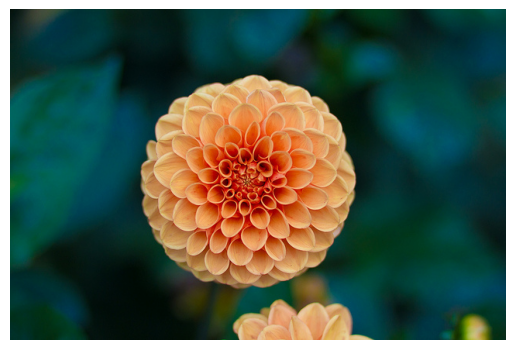

In [120]:
flower = load_sample_image("flower.jpg")#只能讀sklearn範例圖
plt.axis("off")
plt.imshow(flower)

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# flower = mpimg.imread(r"C:\Users\xvpow\ai2_20251025\ch11\flower.jpg")#能讀所有圖

# plt.axis("off")
# plt.imshow(flower)
# plt.show()

## 正規化、取得圖片寬高及顏色維度、將寬高轉為一維

In [121]:
flower = np.array(flower,dtype=np.float64)/255
w,h,d = flower.shape
image_array  = np.reshape(flower,(h*w,d))

print(h,w,d,image_array.shape)


640 427 3 (273280, 3)


In [122]:
image_array[:5]

array([[0.00784314, 0.0745098 , 0.05098039],
       [0.01176471, 0.07058824, 0.05098039],
       [0.02745098, 0.07843137, 0.05098039],
       [0.03137255, 0.08235294, 0.05490196],
       [0.02352941, 0.08235294, 0.05490196]])

In [123]:
image_sample = shuffle(image_array,random_state=42)[:2000]
print(len(image_sample))

2000


In [124]:
kmeans = KMeans(n_clusters=128,random_state=42).fit(image_sample)

In [125]:
labels = kmeans.predict(image_array)

In [126]:
labels[:5]

array([95, 95, 91, 91,  5])

In [127]:
def reconstrcut_image(cluster_centers,labels,w,h):
    d = cluster_centers.shape[1] #代表有幾個顏色
    image = np.zeros((w,h,d))
    lable_index = 0
    for i in range(w):
        for j in  range(h):
            image[i][j] = cluster_centers[labels[lable_index]]
            lable_index += 1
    return image        


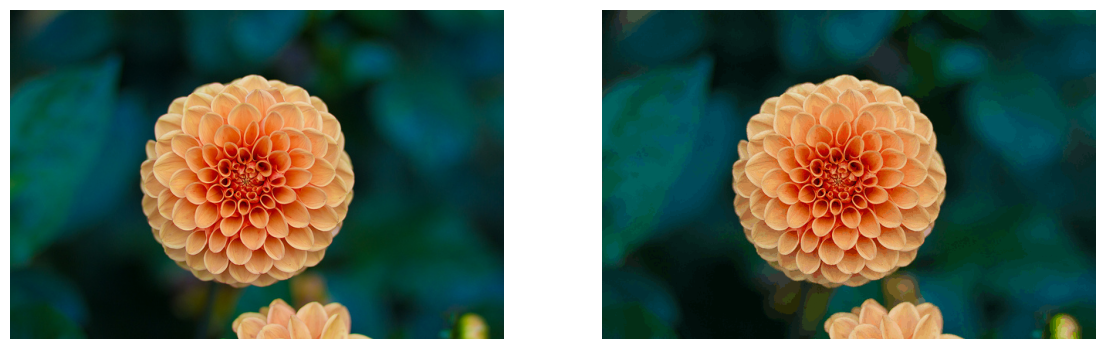

In [128]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.axis("off")
plt.imshow(flower)

plt.subplot(1,2,2)
plt.axis("off")
plt.imshow(reconstrcut_image(kmeans.cluster_centers_,labels,w,h))
#kmeans.cluster_centers_#64個RGB顏色

單一連結（Single-linkage）:

首先確定所有群組間的最短距離，即每個群組中的點與其他群組中的點之間的最短距離。

選擇這些最短距離中的最小值。

將距離最小的那兩個群組合併成一個新的群組。


假設現在有三群：

完整連結:合併後每個群中最遠距離當中最短的那一群合併 因為最遠距離都那麼短了當然跟你合併

A 跟 B：👉 合併後最遠距離 = 10

A 跟 C：👉 合併後最遠距離 = 50

B 跟 C：👉 合併後最遠距離 = 100



In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# 生成一些二維數據
np.random.seed(42)
X = np.random.rand(50, 2)

In [139]:
clustering =  AgglomerativeClustering(n_clusters=3,linkage="ward")#預設沃德連結  
# linkage: Literal['ward', 'complete', 'average', 'single'] = "ward",
clustering.fit(X)

AgglomerativeClustering(n_clusters=3)

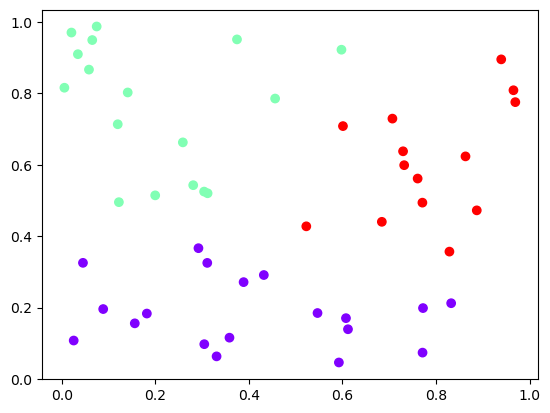

In [140]:
plt.scatter(X[:,0],X[:,1],c=clustering.labels_,cmap="rainbow")
plt.show()

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

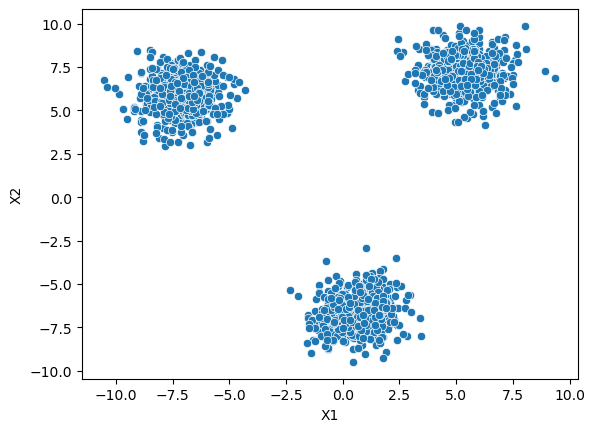

In [144]:
blobs = pd.read_csv("./cluster_blobs.csv")
blobs.head()
sns.scatterplot(x="X1",y="X2",data=blobs)
plt.show()

In [145]:
moons = pd.read_csv("./cluster_moons.csv")
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


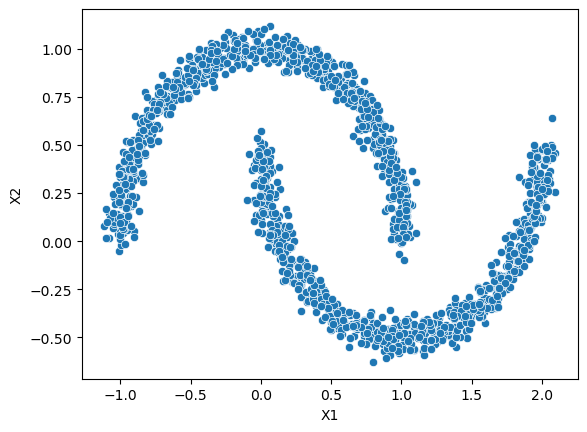

In [147]:
sns.scatterplot(x="X1",y="X2",data=moons)
plt.show()

In [148]:
circles = pd.read_csv("./cluster_circles.csv")
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


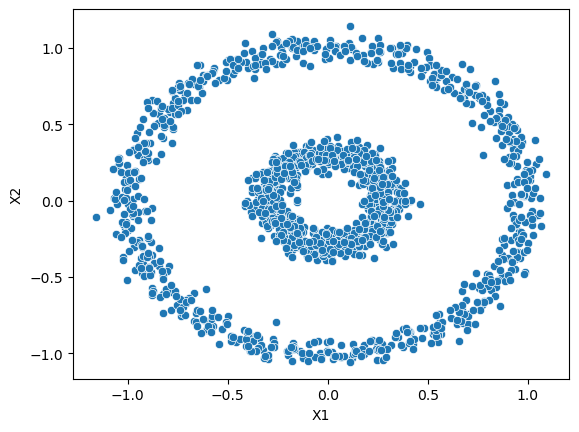

In [149]:
sns.scatterplot(x="X1",y="X2",data=circles)
plt.show()

## 用於顯示群集的散佈圖

In [150]:
def display_mode(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(x="X1",y="X2",hue=labels,data=data,palette="Set1")
    plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


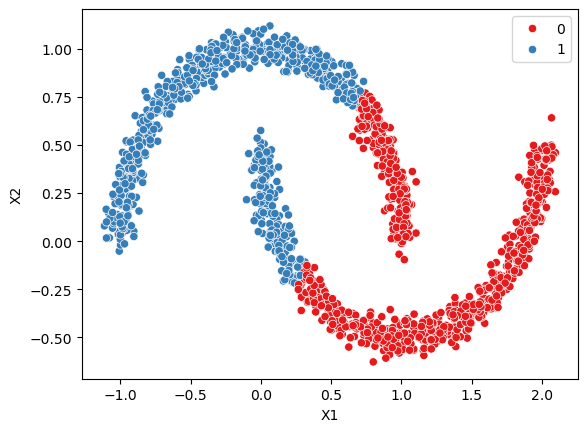

In [151]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, init='k-means++', n_init='auto')
display_mode(model,moons)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


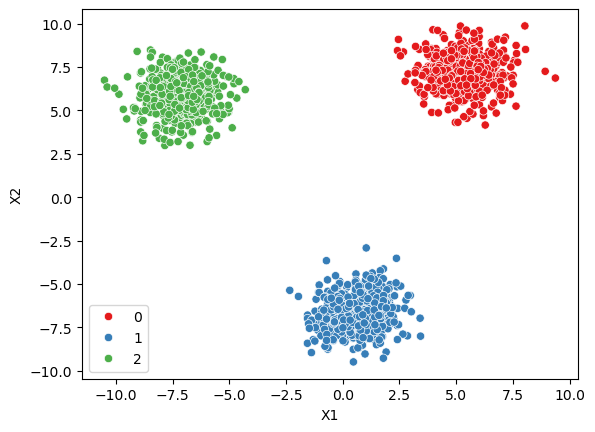

In [152]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, init='k-means++', n_init='auto')
display_mode(model,blobs)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


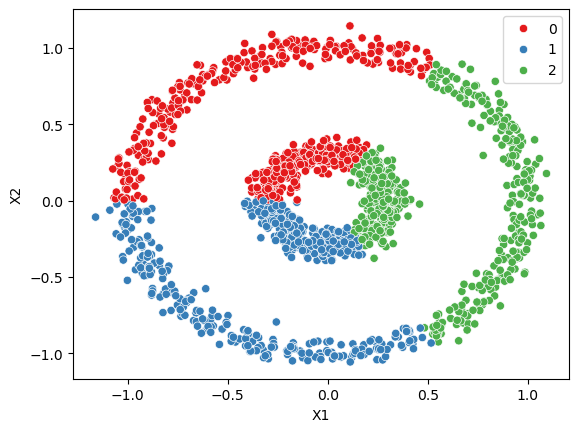

In [165]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, init='k-means++', n_init='auto')
display_mode(model,circles)

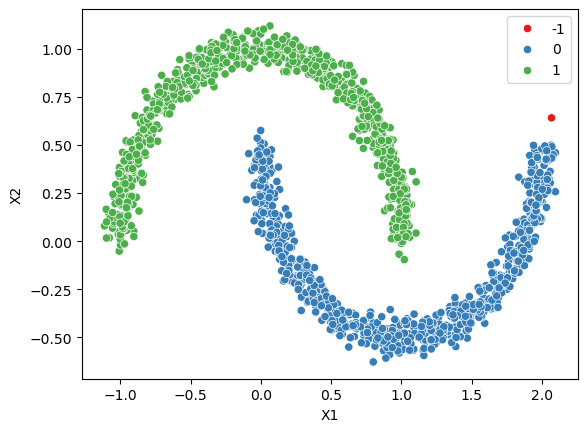

In [ ]:
## DBSCAN 
from sklearn.cluster import DBSCAN
# min_samples: Int = 5 在0.3距離內最少5個樣本點
model = DBSCAN(eps=0.1)
display_mode(model,moons)
#-1是雜訊點

In [163]:
from sklearn.metrics import silhouette_score #輪廓係數
from sklearn.cluster import DBSCAN
import numpy as np
silhouette_scores = []
#silhouette_score 越大越好。
data = moons
eps_values = np.arange(0.1,3.0,0.1)
for eps in eps_values:
    testModel = DBSCAN(eps= eps)
    y_km = testModel.fit_predict(data)
    if len(set(y_km)) > 1:
        silhouette_scores.append(silhouette_score(data,y_km))
    else:
        silhouette_scores.append(-1) 

bast_index = np.argmax(silhouette_scores)        
bast_eps = eps_values[bast_index]
bast_score = silhouette_scores[bast_index]
print(f"eps:{bast_eps} bast_score:{bast_score}")

eps:0.2 bast_score:0.33344160813873897


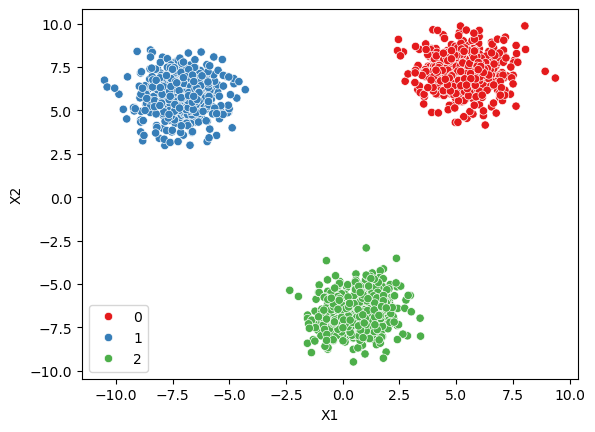

In [162]:
from sklearn.cluster import DBSCAN
mode = DBSCAN(eps=1.5)
display_mode(mode,blobs)

# 半監督式學習

# 自我訓練(Self-training)測試

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier

In [172]:
X,y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=0)

In [173]:
## 設定 約50% 資料為沒有標註(-1)
print(X_train.shape,y_train.shape)

rng = np.random.RandomState(42)
y_rand = rng.rand(y_train.shape[0])#均勻分布亂數
print(len(y_rand))

(120, 4) (120,)
120


In [ ]:
y_50 = np.copy(y_train)
y_50[y_rand < 0.5] = -1#讓約50%的資料為-1為了移除標籤y
print(len(y_50[y_50==-1]))
print(len(y_train))

62
120


In [176]:
base_class = SVC(kernel="rbf",gamma=0.5)
base_class.fit(X_train,y_50)
base_class.score(X_test,y_test)

0.43333333333333335

In [ ]:
base_class = SVC(kernel="rbf",gamma=0.5,probability=True)
#probability 預測的信心值（機率)
clf = SelfTrainingClassifier(base_class).fit(X_train,y_50)
clf.score(X_test,y_test)

1.0